 ##  Customer Segmentation and Retention Analysis
-> Understand customers and
-> Group them
-> Predict who might leave
-> Suggest actions

In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('online_retail_II.xlsx')

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [6]:
pd.set_option('display.max_rows',1000)

In [7]:
df.head(100)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [8]:
df.head(500)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [9]:
df_clean = df.copy()

# Data Cleaning

* Data Cleaning Summary

* Removed transactions without customer identification

* Excluded cancelled and invalid transactions

* Filtered out non-product charges

* Ensured all monetary values represent real purchases

In [10]:
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [11]:
df_clean.shape

(525461, 8)

In [12]:
df_clean['Customer ID'].isnull().any()

np.True_

In [13]:
df_clean['Customer ID'].isnull().sum()

np.int64(107927)

In [14]:
df_clean[df_clean['Customer ID'].isnull()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom


In [15]:
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [16]:
df_clean['Customer ID'].notna()

0         True
1         True
2         True
3         True
4         True
          ... 
525456    True
525457    True
525458    True
525459    True
525460    True
Name: Customer ID, Length: 525461, dtype: bool

In [17]:
# Remove missing customer Id
df_clean = df_clean[df_clean['Customer ID'].notna()]

In [18]:
df_clean.shape

(417534, 8)

In [19]:
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [20]:
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [21]:
# Remove cancelled transactions
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]

In [22]:
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [23]:
# Remove invalid quantity and price
((df_clean['Quantity'] > 0) & (df_clean['Price'] >= 0)).value_counts()

True    407695
Name: count, dtype: int64

In [24]:
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

In [25]:
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [26]:
# Remove non product rows(postage)
#.str.contains() is a vectorized pandas string method that checks whether a substring appears in each element of a Series, 
# and na=False ensures missing values are safely treated as non-matches
df_clean = df_clean[~df_clean['Description'].str.contains('POSTAGE', na=False)]

I used na=False to ensure that missing product descriptions are not mistakenly treated as postage charges, preventing accidental data loss.

In [27]:
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [28]:
# Convert InvoiceDate to DateTime

# Why : We will later compute:

# Recency

# Time gaps

# Churn windows

# Converts the InvoiceDate column into pandas datetime objects so it can be used for time-based analysis

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate']) 



/var/folders/55/d6806_zn1l39xvg_qlwf_tn00000gn/T/ipykernel_1337/2990925217.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])


In [29]:
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [30]:
df_clean['InvoiceDate'].dtype  #NumPy datetime type

dtype('<M8[ns]')

In [31]:
# Create total purchase value this will be used later for Monetary

df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

/var/folders/55/d6806_zn1l39xvg_qlwf_tn00000gn/T/ipykernel_1337/2566616523.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']


In [32]:
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50


In [33]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406926 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      406926 non-null  object        
 1   StockCode    406926 non-null  object        
 2   Description  406926 non-null  object        
 3   Quantity     406926 non-null  int64         
 4   InvoiceDate  406926 non-null  datetime64[ns]
 5   Price        406926 non-null  float64       
 6   Customer ID  406926 non-null  float64       
 7   Country      406926 non-null  object        
 8   TotalPrice   406926 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 31.0+ MB


In [34]:
df_clean.describe()

,Quantity,InvoiceDate,Price,Customer ID,TotalPrice
count,406926.000000,406926,406926.000000,406926.000000,406926.000000
mean,13.604788,2010-07-01 09:58:01.902655744,3.251350,15373.459877,21.584421
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000
25%,2.000000,2010-03-26 14:01:00,1.250000,14006.000000,4.950000
50%,5.000000,2010-07-09 15:31:00,1.950000,15325.000000,11.850000
75%,12.000000,2010-10-14 17:09:00,3.750000,16814.000000,19.500000
max,19152.000000,2010-12-09 20:01:00,10953.500000,18287.000000,15818.400000
std,96.927416,NaN,34.720873,1677.269478,77.153178


In [35]:
df_clean.shape

(406926, 9)

# PART 2 — Customer-Level Aggregation (RFM)

🎯 Goal of Part 2

Transform your cleaned transactional dataset (df_clean) into a customer-level table where:

Each row = one customer

Each column = behavioral signal

Customers become unique

This table (df_rfm) will be the backbone for:

Segmentation

Churn prediction

Interpretation & retention decisions

In [36]:
# define a reference date (one day after the last transaction date)
# defined recency relative to the most recent available transaction date to avoid data leakage
# 2.1
snapshot_date = df_clean['InvoiceDate'].max()+pd.Timedelta(days = 1)  # pd.Timedelta(days = 1) -> a time difference of one day                     
snapshot_date

Timestamp('2010-12-10 20:01:00')

In [37]:
# 2.2 Aggregate to customer Level -> group by CustomerID
df_rfm = (
         df_clean
         .groupby('Customer ID')
         .agg({ 
                'InvoiceDate' : lambda x:(snapshot_date - x.max()).days,# Recency = Reference Date − Customer’s Last Purchase Date
                'Invoice' : 'nunique',
                'TotalPrice' : 'sum'
             })
             .reset_index()
        )



Recency is calculated as the number of days between a fixed snapshot date—defined as one day after the last transaction 
in the dataset—and each customer’s most recent purchase.

“Why not just use today’s date?”

Because:

This dataset ends in the past

Using today would make everyone look extremely inactive

That would be misleading

So I measure recency relative to the dataset’s timeline, not real time.

In [38]:
df_rfm

,Customer ID,InvoiceDate,Invoice,TotalPrice
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,221.16
3,12349.0,43,2,2221.14
4,12351.0,11,1,300.93
...,...,...,...,...
4305,18283.0,18,6,641.77
4306,18284.0,67,1,461.68
4307,18285.0,296,1,427.00
4308,18286.0,112,2,1296.43


In [39]:
# Step 2.3: Rename columns
df_rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [40]:
df_rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,221.16
3,12349.0,43,2,2221.14
4,12351.0,11,1,300.93
...,...,...,...,...
4305,18283.0,18,6,641.77
4306,18284.0,67,1,461.68
4307,18285.0,296,1,427.00
4308,18286.0,112,2,1296.43


In [41]:
# Step 2.4 Sanity checks
df_rfm.shape

(4310, 4)

In [42]:
df_rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4310.000000,4310.000000,4310.000000,4310.000000
mean,15350.612993,91.069142,4.444316,2037.879859
std,1700.483480,96.692083,8.146178,8906.538967
min,12346.000000,1.000000,1.000000,2.950000
25%,13885.000000,18.000000,1.000000,307.390000
50%,15351.500000,53.000000,2.000000,695.925000
75%,16834.750000,136.000000,5.000000,1708.760000
max,18287.000000,374.000000,205.000000,349164.350000


In [43]:
df_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4310 non-null   float64
 1   Recency     4310 non-null   int64  
 2   Frequency   4310 non-null   int64  
 3   Monetary    4310 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 134.8 KB


In [44]:
df_rfm.head(25)

,CustomerID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,221.16
3,12349.0,43,2,2221.14
4,12351.0,11,1,300.93
5,12352.0,11,2,343.80
6,12353.0,44,1,317.76
7,12355.0,203,1,488.21
8,12356.0,16,3,3126.25
9,12357.0,24,1,11229.99


### Customer-Level Aggregation (RFM)

The transactional data was aggregated at the customer level using RFM metrics:
- **Recency**: days since the customer’s most recent purchase
- **Frequency**: number of unique purchase invoices
- **Monetary**: total spending across all transactions

This transformation converts raw transaction logs into interpretable customer behavior features.


In [45]:
df_rfm[['Recency', 'Frequency','Monetary']].describe() 

,Recency,Frequency,Monetary
count,4310.000000,4310.000000,4310.000000
mean,91.069142,4.444316,2037.879859
std,96.692083,8.146178,8906.538967
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.390000
50%,53.000000,2.000000,695.925000
75%,136.000000,5.000000,1708.760000
max,374.000000,205.000000,349164.350000


A histogram answers ONE simple question:

“How many data points fall into different value ranges?”

That’s it.

It shows:

how values are distributed

where most values lie

whether extreme values (outliers) exist

array([[<Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Frequency'}>],
       [<Axes: title={'center': 'Monetary'}>, <Axes: >]], dtype=object)

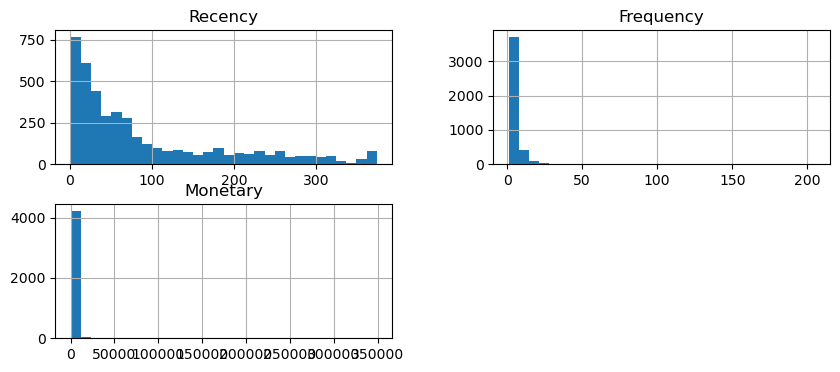

In [47]:
# Skewness is named after the direction of the TAIL, not the bars.
# Right-skewed means “a few very large values pull the distribution to the right.
df_rfm[['Recency','Frequency','Monetary']].hist (bins = 30, figsize =(10,4)) 

X-axis and Y-axis (this is crucial)

🔹 X-axis (horizontal)

X-axis = the values of the variable

In this case, we plotted three variables:

Recency histogram

X-axis = number of days since last purchase

Frequency histogram

X-axis = number of purchases

Monetary histogram

X-axis = total amount spent

Each bar on the X-axis represents a range of values, not one single value


🔹 Y-axis (vertical)

Y-axis = number of customers

It answers:

“How many customers fall into this value range?”

So:

Taller bar = more customers

Shorter bar = fewer customers



3️⃣ How to read ANY histogram (step-by-step)

Always ask these 4 questions:

Where are most bars concentrated?

Is the distribution balanced or skewed?

Are there extreme values (long tails)?

What does this say about behavior?



4 This Recency Histogram (Top-Left)

X-axis

Days since last purchase (0 → ~370)

Y-axis

Number of customers

What we see

Tall bars on the left

Bars get shorter as you go right

What it means

Many customers bought recently

Fewer customers haven’t bought for a long time

Interpretation in business language

Most customers are still active

A smaller group is drifting away

A very small group is highly inactive

Key phrase

Recency is right-skewed

This is normal for retail data.


5️⃣ Our Frequency Histogram (Top-Right)
X-axis

Number of purchases (1 → ~200)

Y-axis

Number of customers

What you see

Huge spike near 1–2 purchases

Very long empty space to the right

What it means

Most customers buy only once or twice

A small number buy many times

Interpretation in business language

Many one-time buyers

Few loyal repeat customers

Important insight

Loyal customers are rare but valuable



6️⃣ Our Monetary Histogram (Bottom-Left)

X-axis

Total money spent (small → very large)

Y-axis

Number of customers

What you see

Almost everything squeezed to the left

Long empty stretch to the right

What it means

Most customers spend small amounts

A few customers spend huge amounts

Why it looks “flat”

Because a few very large spenders stretch the scale.

Example:

Most customers: £100–£1000

One customer: £349,000

The axis stretches to include the big value.


7️⃣ What “skewed” means 

Our histograms are right-skewed.

That means:

Most values are small

Few values are very large

The “tail” goes to the right

This is expected in customer data.


8️⃣ Why histograms matter in OUR project

Our histograms are telling you:

❌ Raw RFM values are not evenly distributed
❌ Monetary dominates everything
❌ Distance-based models will be biased

That is WHY we are going to do:

log transformation

scaling

This step was necessary, not optional.

### Histogram Interpretation

Histograms show the distribution of RFM features across customers.
The X-axis represents the value range of each feature, while the Y-axis represents the number of customers.

The distributions of Recency, Frequency, and Monetary are heavily right-skewed.
Most customers are recently active, make few purchases, and spend relatively small amounts, while a small number of customers contribute disproportionately high purchase frequency and monetary value.

These characteristics justify log transformation and feature scaling prior to clustering.


🔟 Final mental model (remember this forever)

Think of a histogram like grouping people by height:

X-axis = height ranges

Y-axis = number of people in each range

Same logic — different variable.

The RFM features are right-skewed, meaning most customers have low values while a small number of customers exhibit extremely high values, 
creating a long tail on the right side of the distribution.”

df_rfm for interpretation and business decisions

df_rfm_log for modeling and clustering

In [48]:
import numpy as np

df_rfm_log = df_rfm.copy() # df_rfm_log = math-friendly version

df_rfm_log['Recency']   = np.log1p(df_rfm_log['Recency']) # Compress large values, keep relative differences
df_rfm_log['Frequency'] = np.log1p(df_rfm_log['Frequency'])
df_rfm_log['Monetary']  = np.log1p(df_rfm_log['Monetary'])



df_rfm_log was created to reduce skewness and compress extreme RFM values so that distance-based clustering 
reflects overall customer behavior rather than being domin

* Large values are pulled closer

* Small values still differ meaningfully

* No information is lost, just rescaled

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    df_rfm_log[['Recency', 'Frequency', 'Monetary']]
)


In [50]:
df_rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=df_rfm_log['CustomerID']
)


df_rfm_log fixes skewness.
rfm_scaled fixes scale.

They solve two different problems.

What scaling does

For each feature:

Mean → 0

Standard deviation → 1

So now:

All features live on the same scale

Each feature contributes fairly to distance

Key idea

rfm_scaled =
👉 “Mathematically fair version for clustering.”

| Object       | Purpose                    | Human-readable? | Used for                  |
| ------------ | -------------------------- | --------------- | ------------------------- |
| `df_rfm`     | Raw customer behavior      | ✅ Yes          | Interpretation, reporting |
| `df_rfm_log` | Reduce skewness            | ⚠️ Semi         | Prep step                 |
| `rfm_scaled` | Equalize feature influence | ❌ No           | K-Means clustering        |


df_rfm  →  df_rfm_log  →  rfm_scaled
(real)      (less skew)   (fair distance)


In [51]:
df_rfm_scaled

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,0.966991,1.616874,-0.536272
12347.0,-1.900371,-0.392911,0.452446
12348.0,0.355530,-0.980735,-0.943152
12349.0,-0.054907,-0.392911,0.857050
12351.0,-1.054859,-0.980735,-0.703318
...,...,...,...
18283.0,-0.701194,0.835462,-0.112645
18284.0,0.280122,-0.980735,-0.369641
18285.0,1.414712,-0.980735,-0.430548


I applied log transformation to reduce skewness in RFM features, 
then standardized the transformed values to ensure equal contribution during distance-based clustering.

### RFM Preparation for Segmentation

RFM features exhibited significant right skew, particularly for Frequency and Monetary.
To address this:
- Log transformation was applied to reduce skewness
- Features were standardized to ensure equal contribution during clustering

This preprocessing ensures stable and interpretable customer segmentation.


In [52]:
# PART 2.2 — Customer Segmentation (Clustering)
# Method: Elbow Method

from sklearn.cluster import KMeans

inertia = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_rfm_scaled)
    inertia.append(kmeans.inertia_)


What is the Elbow Method?

The Elbow Method is a technique used in K-Means clustering to decide:

How many clusters (k) should we choose?

Why do we need it?

K-Means cannot decide k by itself.
We must tell it how many clusters to create.

The Elbow Method helps us choose a reasonable number, not too few and not too many.

How does it work?

We try different values of k (for example: 2, 3, 4, 5, …)

For each k, K-Means calculates inertia

What is inertia?

Inertia = how far customers are from their cluster center
(lower is better)

We plot:

X-axis → number of clusters (k)

Y-axis → inertia

What do you look for?

You look for a point where:

Adding more clusters does not improve things much anymore

This point looks like a bend in the graph — like an elbow.

👉 That bend is the best k.


The Elbow Method is a technique used to select the optimal number of clusters by identifying the point
where adding more clusters results in diminishing improvement.

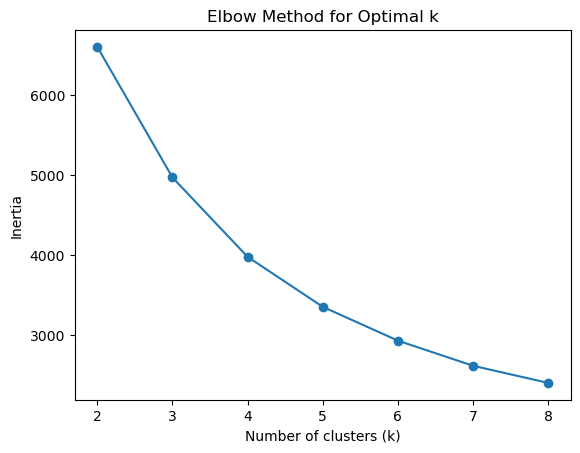

In [53]:
import matplotlib.pyplot as plt

plt.plot(range(2, 9), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


In [54]:
# k = 4

# Why?

# Easy to interpret

# Business-friendly

# Common in RFM analysis

# Enough separation without overfitting

kmeans = KMeans(n_clusters=4, random_state=42)
df_rfm['Cluster'] = kmeans.fit_predict(df_rfm_scaled)


Now:

Each customer belongs to a cluster

Segmentation is complete (technically)

In [55]:
cluster_summary = (
    df_rfm
    .groupby('Cluster')
    .agg({
        'Recency': 'mean',
        'Frequency': 'mean',
        'Monetary': 'mean'
    })
    .round(1)
)

cluster_summary


,Recency,Frequency,Monetary
Cluster,,,
0,22.8,2.1,567.9
1,13.9,13.6,7397.7
2,82.7,4.1,1779.3
3,186.4,1.3,300.2


In [56]:
cluster_labels = {
    0: 'Active Low-Value',
    1: 'High-Value Loyal',
    2: 'At-Risk High-Value',
    3: 'Inactive / Churned'
}

df_rfm['Segment'] = df_rfm['Cluster'].map(cluster_labels)


Remember:

Lower Recency = better

Higher Frequency = better

Higher Monetary = better


| Cluster Type       | Typical Pattern       |
| ------------------ | --------------------- |
| High-Value Loyal   | Low R, High F, High M |
| At-Risk High-Value | High R, High M        |
| Active Low-Value   | Low R, Low M          |
| Inactive / Churned | High R, Low F, Low M  |


* Cluster IDs are assigned arbitrarily by the algorithm, so interpretation is based on RFM characteristics 
  rather than the numeric label




Customer segments were defined based on RFM behavior and interpreted in terms of business value and churn risk, 
enabling targeted and cost-effective retention strategies.

### Cluster Interpretation

The clustering results reveal four distinct customer segments.
Notably, the High-Value Loyal segment is characterized by low recency, high frequency, and high monetary value.
Other segments include active low-value customers, at-risk high-value customers, and inactive customers likely to churn.

Cluster labels were assigned based on behavioral patterns rather than numeric cluster IDs.


In [57]:
# Churn is Purchase inactivity over a chosen time window

churn_threshold = 90

df_rfm['Churn'] = (df_rfm['Recency'] > churn_threshold).astype(int)


In [58]:
df_rfm['Churn'].value_counts(normalize=True)


Churn
0    0.667285
1    0.332715
Name: proportion, dtype: float64

In [59]:
# Prepare Data for Churn Modeling

X = df_rfm[['Recency', 'Frequency', 'Monetary']]
y = df_rfm['Churn']


In [60]:
# Tran Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


# STEP 3.3 — Train a Simple, Interpretable Model

We start with Logistic Regression because:

Easy to interpret

Business-friendly

Logistic Regression is a supervised learning algorithm used for binary classification that models the probability of an outcome and allows interpretable, probability-based decisions

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


I initialized a Logistic Regression model and trained it using labeled training data 
so it could learn the relationship between RFM features and customer churn

In [ ]:
# 🔹 STEP 3.4 — Evaluate the Model (Interpretation-Focused)

from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


In [ ]:
# STEP 3.5 — Get Churn Probability

df_rfm['Churn_Probability'] = model.predict_proba(X)[:, 1]

# This line calculates the probability that each customer will churn and stores it in a new column called Churn_Probability

Now each customer has:

* Segment

* Value

* Churn risk

This is real AI decision support.

In [ ]:
# STEP 3.6 — Combine Segment + Churn Risk

def retention_action(row):
    if row['Segment'] == 'High-Value Loyal' and row['Churn_Probability'] > 0.5:
        return 'Immediate Retention (VIP Offer)'
    elif row['Segment'] == 'At-Risk High-Value' and row['Churn_Probability'] > 0.4:
        return 'Targeted Win-Back Campaign'
    elif row['Segment'] == 'Active Low-Value' and row['Churn_Probability'] > 0.5:
        return 'Upsell / Engagement Offer'
    elif row['Segment'] == 'Inactive / Churned':
        return 'No Action / Low-Cost Re-engagement'
    else:
        return 'Monitor'


In [ ]:
df_rfm['Retention_Action'] = df_rfm.apply(retention_action, axis=1)


In [ ]:
df_rfm

In [ ]:
import joblib
joblib.dump(scaler,  "models/scaler.pkl")
joblib.dump(kmeans,  "models/kmeans.pkl")
joblib.dump(model,   "models/churn_model.pkl")


### Churn Prediction & Retention Strategy

Churn was defined as customer inactivity beyond 90 days.
A logistic regression model was trained using RFM features to estimate churn probability.

Rather than focusing solely on prediction accuracy, churn risk was combined with customer segment value to drive retention decisions.
This approach enables targeted, cost-effective retention strategies aligned with business value.
